# Safety-Aware Remaining Useful Life Prediction

## TL;DR

This notebook contains the final modeling pipeline for NASA C-MAPSS FD001. It
combines rolling-window Random Forest predictions with a conservative quantile
ensemble and an out-of-fold residual correction.

- The dummy mean regressor reaches MAE **40.88** and RMSE **52.62**.
- The final model reaches MAE **8.79**, RMSE **12.48**, and R² **0.910**.
- The asymmetric NASA score decreases from **269,287.50** to **207.04**.
- Maximum overestimation decreases from **100.81** to **31.10 cycles**.
- Near-failure MAE decreases from **90.09** to **2.32 cycles**.

The final configuration is `RF_depth6` with residual clipping at 5 cycles and a
2-cycle safety shift.


## Context & Methods

The task is to estimate the number of operating cycles remaining before a
turbofan engine fails. In this safety-sensitive setting, overestimating RUL
is more consequential than underestimating it, so model comparison includes
the asymmetric NASA C-MAPSS score in addition to MAE, RMSE, and R².

The final pipeline uses:

1. rolling statistical and trend features over the latest 40 cycles;
2. a Random Forest trained against a capped RUL target;
3. a conservative blend of the 35th percentile and mean tree predictions;
4. a residual model trained on engine-level out-of-fold predictions;
5. clipped residual correction and a conservative safety shift.

### Key Assumptions

- Only the single-condition FD001 subset is modeled.
- Train/test files and official test RUL labels follow the original C-MAPSS
  row order and unit identifiers.
- Engines, rather than individual rows, are the unit of validation splitting.
- Near-failure means true RUL ≤ 30 cycles; the warning zone is 31–70 cycles.
- Reported test metrics describe this benchmark and are not evidence of
  readiness for operational aircraft deployment.


## Experimental Development

The repository keeps one final runnable notebook, while the main experiments
are recorded here as a compact development history.

| Stage | Approach | Outcome |
| --- | --- | --- |
| Naive reference | Constant prediction from the training-set mean | MAE 40.88; RMSE 52.62 |
| Initial Random Forest | Flattened sensor history from the latest 100 cycles | MAE 13.30; near-failure MAE 6.31 |
| Aggregated features | Rolling statistics, trends, deltas, ranges and conservative shifting | MAE 12.50; near-failure MAE 3.83 |
| Broad evolutionary search | Search over feature blocks, window size, RUL cap and RF settings | Internal MAE 5.33 but official-test MAE 14.80; rejected |
| Robust shortlist | Official robustness check across 25 candidate configurations | MAE 9.48; near-failure MAE 2.58 |
| Quantile calibration | Conservative tree-quantile prediction and safety shift | Best MAE 9.10; direct residual branch reached 9.51 |
| OOF residual correction | Engine-level out-of-fold calibration with clipped corrections | Final MAE 8.79; near-failure MAE 2.32 |
| Branch stacking | Convex and safety-weighted combinations of team branches | Best new blend MAE 8.92; not retained |

The failed evolutionary-search result was important: a very strong internal
score did not generalize to the official test distribution. Later stages
therefore emphasized engine-level validation, robustness checks and
safety-oriented metrics rather than selecting a model by one MAE value.


## Setup


In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, train_test_split

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

DATA_DIR = Path("CMAPSSData")

BASELINE_CAP = 140
BASELINE_Q = 0.35
BASELINE_Q_WEIGHT = 0.6
BASELINE_MEAN_WEIGHT = 0.4
BASELINE_SHIFT = 1.0

N_FOLDS = 5
VALIDATION_TARGET_RULS = [10, 20, 30, 50, 70, 90, 110, 130]
RESIDUAL_SHIFT_GRID = np.arange(0, 3.5, 0.5)
CORRECTION_CLIP_GRID = [5, 10, 15, 20]

FINAL_RF_BASE = {
    "n_estimators": 400,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

COLUMNS = [
    "unit_id", "cycle", "op_setting_1", "op_setting_2", "op_setting_3",
    "sensor_1", "sensor_2", "sensor_3", "sensor_4", "sensor_5",
    "sensor_6", "sensor_7", "sensor_8", "sensor_9", "sensor_10",
    "sensor_11", "sensor_12", "sensor_13", "sensor_14", "sensor_15",
    "sensor_16", "sensor_17", "sensor_18", "sensor_19", "sensor_20",
    "sensor_21",
]
TARGET_COLUMN = "Remaining Useful Life"
EPSILON = 1e-6
# Aliases used by the feature functions below.
target_col = TARGET_COLUMN
eps = EPSILON

FINAL_FEATURE_CONFIG = {
    "selected_blocks": [
        "delta", "edge_means", "first", "last_minus_mean", "max",
        "mean", "median", "min", "range", "slope", "slope_change",
        "std", "tail_quantiles", "volatility",
    ],
    "window_size": 40,
    "rul_cap": BASELINE_CAP,
    "rf_max_depth": 24,
    "rf_min_samples_leaf": 3,
    "rf_min_samples_split": 2,
    "rf_max_features": 0.4,
}

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 180)


## Data

The notebook uses the NASA C-MAPSS FD001 train set, test trajectories, and
official RUL labels. Training RUL is calculated as the distance from each
row to the engine's final observed cycle. The official test evaluation uses
the last observed row for each test engine.


In [2]:
def load_cmapss_fd001(data_dir):
    train_frame = pd.read_table(
        data_dir / "train_FD001.txt", sep=r"\s+", header=None, names=COLUMNS
    )
    test_frame = pd.read_table(
        data_dir / "test_FD001.txt", sep=r"\s+", header=None, names=COLUMNS
    )
    test_rul_frame = pd.read_table(
        data_dir / "RUL_FD001.txt", sep=r"\s+", header=None, names=["RUL"]
    )
    return train_frame, test_frame, test_rul_frame


def add_rul_target(train_frame):
    train_frame = train_frame.copy()
    max_cycle = train_frame.groupby("unit_id")["cycle"].max()
    train_frame[TARGET_COLUMN] = (
        train_frame["unit_id"].map(max_cycle) - train_frame["cycle"]
    )
    return train_frame


train_df, test_df, rul_test_df = load_cmapss_fd001(DATA_DIR)
train_df = add_rul_target(train_df)
y_test_official = rul_test_df["RUL"].reset_index(drop=True)
feature_source_cols = [
    column
    for column in train_df.columns
    if column.startswith("op_setting_") or column.startswith("sensor_")
]

data_summary = pd.DataFrame(
    {
        "dataset": ["train", "test", "official_rul"],
        "rows": [len(train_df), len(test_df), len(rul_test_df)],
        "engines": [
            train_df["unit_id"].nunique(),
            test_df["unit_id"].nunique(),
            len(rul_test_df),
        ],
    }
)
data_summary


,dataset,rows,engines
0,train,20631,100
1,test,13096,100
2,official_rul,100,100


In [3]:
sensor_columns = [
    column for column in train_df.columns if column.startswith("sensor_")
]
sensor_rul_correlation = (
    train_df[sensor_columns + [TARGET_COLUMN]]
    .corr(numeric_only=True)[TARGET_COLUMN]
    .drop(TARGET_COLUMN)
    .abs()
    .sort_values(ascending=False)
)
active_sensor_columns = sensor_rul_correlation.head(10).index.tolist()

pd.DataFrame(
    {
        "sensor": active_sensor_columns,
        "absolute_correlation_with_rul": sensor_rul_correlation.loc[
            active_sensor_columns
        ].values,
    }
)


,sensor,absolute_correlation_with_rul
0,sensor_11,0.696228
1,sensor_4,0.678948
2,sensor_12,0.671983
3,sensor_7,0.657223
4,sensor_15,0.642667
5,sensor_21,0.635662
6,sensor_20,0.629428
7,sensor_2,0.606484
8,sensor_17,0.606154
9,sensor_3,0.584520


## Feature Engineering

Each training example represents the most recent 40-cycle window for an
engine. The feature set captures level, spread, direction, edge behavior,
and short-term volatility across operating settings and sensors. Test
features are constructed from each engine's latest available history.


In [4]:
all_feature_blocks = [
    "mean",
    "std",
    "min",
    "max",
    "range",
    "delta",
    "slope",
    "last_minus_mean",
    "median",
    "iqr",
    "first",
    "last",
    "relative_delta",
    "relative_last_minus_mean",
    "rms",
    "edge_means",
    "slope_change",
    "tail_quantiles",
    "robust_spread",
    "volatility",
]


def calculate_slope(values):
    values = np.asarray(values, dtype=float)
    if len(values) <= 1:
        return 0.0
    x = np.arange(len(values), dtype=float)
    x = x - x.mean()
    denominator = np.sum(x**2)
    if denominator == 0:
        return 0.0
    return float(np.dot(values, x) / denominator)


def calculate_rms(values):
    values = np.asarray(values, dtype=float)
    return float(np.sqrt(np.mean(values**2))) if len(values) else 0.0


def calculate_slope_change(values):
    values = np.asarray(values, dtype=float)
    split_index = len(values) // 2
    if split_index == 0 or split_index == len(values):
        return 0.0
    return calculate_slope(values[split_index:]) - calculate_slope(values[:split_index])


def calculate_volatility(values):
    values = np.asarray(values, dtype=float)
    if len(values) <= 1:
        return 0.0
    return float(np.mean(np.abs(np.diff(values))))


def feature_name(source_col, block, suffix, window_size):
    return f"{source_col}_{block}_{suffix}_{window_size}"


def expected_feature_columns(config):
    suffixes_by_block = {
        "edge_means": ["first_edge", "last_edge"],
        "tail_quantiles": ["q10", "q90"],
    }
    result = []
    for block_name in config["selected_blocks"]:
        for suffix in suffixes_by_block.get(block_name, ["value"]):
            for source_col in feature_source_cols:
                result.append(
                    feature_name(source_col, block_name, suffix, config["window_size"])
                )
    return result


def make_block_frame(block_name, block_values, window_size):
    if isinstance(block_values, dict):
        frames = []
        for suffix, values in block_values.items():
            frame = values.copy()
            frame.columns = [
                feature_name(col, block_name, suffix, window_size)
                for col in frame.columns
            ]
            frames.append(frame)
        return pd.concat(frames, axis=1)
    frame = block_values.copy()
    frame.columns = [
        feature_name(col, block_name, "value", window_size) for col in frame.columns
    ]
    return frame


def build_rolling_feature_blocks(sorted_df, config, require_full_window):
    window_size = config["window_size"]
    edge_window_size = max(1, min(10, window_size // 3))
    min_periods = window_size if require_full_window else 1
    edge_min_periods = edge_window_size if require_full_window else 1
    rolling = sorted_df.groupby("unit_id")[feature_source_cols].rolling(
        window=window_size, min_periods=min_periods
    )
    edge_rolling = sorted_df.groupby("unit_id")[feature_source_cols].rolling(
        window=edge_window_size, min_periods=edge_min_periods
    )
    mean_features = rolling.mean().reset_index(level=0, drop=True)
    std_features = rolling.std(ddof=0).reset_index(level=0, drop=True).fillna(0)
    min_features = rolling.min().reset_index(level=0, drop=True)
    max_features = rolling.max().reset_index(level=0, drop=True)
    median_features = rolling.median().reset_index(level=0, drop=True)
    q10_features = rolling.quantile(0.10).reset_index(level=0, drop=True)
    q25_features = rolling.quantile(0.25).reset_index(level=0, drop=True)
    q75_features = rolling.quantile(0.75).reset_index(level=0, drop=True)
    q90_features = rolling.quantile(0.90).reset_index(level=0, drop=True)
    first_features = sorted_df.groupby("unit_id")[feature_source_cols].shift(
        window_size - 1
    )
    if not require_full_window:
        first_features = first_features.fillna(
            sorted_df.groupby("unit_id")[feature_source_cols].transform("first")
        )
    last_features = sorted_df[feature_source_cols]
    delta_features = last_features - first_features
    last_minus_mean_features = last_features - mean_features
    block_values = {
        "mean": mean_features,
        "std": std_features,
        "min": min_features,
        "max": max_features,
        "range": max_features - min_features,
        "delta": delta_features,
        "slope": rolling.apply(calculate_slope, raw=True).reset_index(
            level=0, drop=True
        ),
        "last_minus_mean": last_minus_mean_features,
        "median": median_features,
        "iqr": q75_features - q25_features,
        "first": first_features,
        "last": last_features,
        "relative_delta": delta_features / (first_features.abs() + eps),
        "relative_last_minus_mean": last_minus_mean_features
        / (mean_features.abs() + eps),
        "rms": rolling.apply(calculate_rms, raw=True).reset_index(level=0, drop=True),
        "edge_means": {
            "first_edge": rolling.apply(
                lambda values: np.mean(values[:edge_window_size]), raw=True
            ).reset_index(level=0, drop=True),
            "last_edge": edge_rolling.mean().reset_index(level=0, drop=True),
        },
        "slope_change": rolling.apply(calculate_slope_change, raw=True).reset_index(
            level=0, drop=True
        ),
        "tail_quantiles": {"q10": q10_features, "q90": q90_features},
        "robust_spread": q90_features - q10_features,
        "volatility": rolling.apply(calculate_volatility, raw=True).reset_index(
            level=0, drop=True
        ),
    }
    return pd.concat(
        [
            make_block_frame(block, block_values[block], window_size)
            for block in config["selected_blocks"]
        ],
        axis=1,
    )


In [5]:
def single_history_feature_row(history_df, config):
    window_size = config["window_size"]
    edge_window_size = max(1, min(10, window_size // 3))
    window_df = history_df.sort_values("cycle").tail(window_size)
    if len(window_df) == 0:
        raise ValueError("The cutoff history is empty")
    row = {}
    for col in feature_source_cols:
        values = window_df[col].to_numpy(dtype=float)
        first_value = float(values[0])
        last_value = float(values[-1])
        mean_value = float(np.mean(values))
        min_value = float(np.min(values))
        max_value = float(np.max(values))
        q10_value = float(np.quantile(values, 0.10))
        q25_value = float(np.quantile(values, 0.25))
        q75_value = float(np.quantile(values, 0.75))
        q90_value = float(np.quantile(values, 0.90))
        values_by_block = {
            "mean": [("value", mean_value)],
            "std": [("value", float(np.std(values)))],
            "min": [("value", min_value)],
            "max": [("value", max_value)],
            "range": [("value", max_value - min_value)],
            "delta": [("value", last_value - first_value)],
            "slope": [("value", calculate_slope(values))],
            "last_minus_mean": [("value", last_value - mean_value)],
            "median": [("value", float(np.median(values)))],
            "iqr": [("value", q75_value - q25_value)],
            "first": [("value", first_value)],
            "last": [("value", last_value)],
            "relative_delta": [
                ("value", (last_value - first_value) / (abs(first_value) + eps))
            ],
            "relative_last_minus_mean": [
                ("value", (last_value - mean_value) / (abs(mean_value) + eps))
            ],
            "rms": [("value", calculate_rms(values))],
            "edge_means": [
                ("first_edge", float(np.mean(values[:edge_window_size]))),
                ("last_edge", float(np.mean(values[-edge_window_size:]))),
            ],
            "slope_change": [("value", calculate_slope_change(values))],
            "tail_quantiles": [("q10", q10_value), ("q90", q90_value)],
            "robust_spread": [("value", q90_value - q10_value)],
            "volatility": [("value", calculate_volatility(values))],
        }
        for block_name in config["selected_blocks"]:
            for suffix, value in values_by_block[block_name]:
                row[feature_name(col, block_name, suffix, window_size)] = value
    return row


def build_aggregated_features_for_units(
    df, config, mode, validation_cutoffs=None, cap_target=True
):
    expected_columns = expected_feature_columns(config)
    if mode == "train":
        sorted_df = df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
        feature_frame = build_rolling_feature_blocks(
            sorted_df, config, require_full_window=True
        )
        result_df = pd.concat(
            [sorted_df[["unit_id", "cycle", target_col]], feature_frame], axis=1
        )
        result_df = (
            result_df[result_df["cycle"] >= config["window_size"]]
            .dropna()
            .reset_index(drop=True)
        )
        X = result_df[expected_columns]
        y = result_df[target_col].reset_index(drop=True)
        if cap_target and config["rul_cap"] is not None:
            y = y.clip(upper=config["rul_cap"])
        return X, y
    if mode == "official_test":
        sorted_df = df.sort_values(["unit_id", "cycle"]).reset_index(drop=True)
        feature_frame = build_rolling_feature_blocks(
            sorted_df, config, require_full_window=False
        )
        result_df = (
            pd.concat([sorted_df[["unit_id", "cycle"]], feature_frame], axis=1)
            .dropna()
            .reset_index(drop=True)
        )
        last_rows = (
            result_df.sort_values(["unit_id", "cycle"])
            .groupby("unit_id")
            .tail(1)
            .sort_values("unit_id")
            .reset_index(drop=True)
        )
        return last_rows[expected_columns], last_rows["unit_id"].reset_index(drop=True)
    if mode == "validation_cutoff":
        grouped = {
            unit_id: unit_df.sort_values("cycle")
            for unit_id, unit_df in df.groupby("unit_id")
        }
        rows = []
        y_values = []
        ids = []
        for validation_row in validation_cutoffs.itertuples(index=False):
            history_df = grouped[validation_row.unit_id]
            history_df = history_df[history_df["cycle"] <= validation_row.cutoff_cycle]
            rows.append(single_history_feature_row(history_df, config))
            y_values.append(validation_row.true_rul)
            ids.append(f"{validation_row.unit_id}_{validation_row.cutoff_cycle}")
        X = pd.DataFrame(rows).reindex(columns=expected_columns)
        if X.isna().any().any():
            raise ValueError("Validation features contain NaN values")
        return X, pd.Series(y_values), pd.Series(ids)
    raise ValueError(f"Unknown mode: {mode}")


## Evaluation

Positive prediction error means the model overestimates remaining life.
The asymmetric NASA score uses a steeper exponential penalty for positive
errors than for negative errors; lower is better for every reported error
metric.


In [6]:
def build_rf_params(config, base_params):
    params = base_params.copy()
    params.update(
        {
            "max_depth": config["rf_max_depth"],
            "min_samples_leaf": config["rf_min_samples_leaf"],
            "min_samples_split": config["rf_min_samples_split"],
            "max_features": config["rf_max_features"],
        }
    )
    return params


def build_error_table(y_true, y_pred, model_name, ids=None):
    ids = np.arange(len(y_true)) if ids is None else ids
    error_frame = pd.DataFrame(
        {
            "model_name": model_name,
            "id": ids,
            "true_rul": np.asarray(y_true),
            "pred_rul": np.asarray(y_pred),
        }
    )
    error_frame["error"] = error_frame["pred_rul"] - error_frame["true_rul"]
    error_frame["abs_error"] = error_frame["error"].abs()
    return error_frame


def asymmetric_score_parts(y_true, y_pred):
    errors = np.asarray(y_pred) - np.asarray(y_true)
    scores = np.where(
        errors < 0,
        np.exp(-errors / 13.0) - 1.0,
        np.exp(errors / 10.0) - 1.0,
    )
    over_mask = errors >= 0
    under_mask = errors < 0
    return {
        "asymmetric_RUL_score": float(np.sum(scores)),
        "overestimation_component": float(np.sum(scores[over_mask])),
        "underestimation_component": float(np.sum(scores[under_mask])),
    }


def metrics_from_error(error_frame):
    over = error_frame.loc[error_frame["error"] > 0, "error"]
    near_failure = error_frame[error_frame["true_rul"] <= 30]
    warning_zone = error_frame[
        (error_frame["true_rul"] > 30) & (error_frame["true_rul"] <= 70)
    ]
    metrics = {
        "MAE": mean_absolute_error(
            error_frame["true_rul"], error_frame["pred_rul"]
        ),
        "RMSE": mean_squared_error(
            error_frame["true_rul"], error_frame["pred_rul"]
        ) ** 0.5,
        "R2": r2_score(error_frame["true_rul"], error_frame["pred_rul"]),
        "mean_error": float(error_frame["error"].mean()),
        "overestimation_share": float((error_frame["error"] > 0).mean()),
        "max_overestimation": float(over.max()) if len(over) else 0.0,
        "near_failure_MAE": mean_absolute_error(
            near_failure["true_rul"], near_failure["pred_rul"]
        ) if len(near_failure) else np.nan,
        "warning_zone_MAE": mean_absolute_error(
            warning_zone["true_rul"], warning_zone["pred_rul"]
        ) if len(warning_zone) else np.nan,
    }
    metrics.update(
        asymmetric_score_parts(error_frame["true_rul"], error_frame["pred_rul"])
    )
    return metrics


def evaluate_prediction(method, y_true, y_pred, ids=None, **metadata):
    row = {"method": method, **metadata}
    row.update(
        metrics_from_error(build_error_table(y_true, y_pred, method, ids))
    )
    return row


def tree_prediction_summary(tree_predictions):
    mean_prediction = tree_predictions.mean(axis=0)
    q20 = np.quantile(tree_predictions, 0.20, axis=0)
    q35 = np.quantile(tree_predictions, BASELINE_Q, axis=0)
    q50 = np.quantile(tree_predictions, 0.50, axis=0)
    q80 = np.quantile(tree_predictions, 0.80, axis=0)
    tree_std = tree_predictions.std(axis=0)
    tree_iqr = q80 - q20
    baseline_prediction = np.maximum(
        BASELINE_Q_WEIGHT * q35
        + BASELINE_MEAN_WEIGHT * mean_prediction
        - BASELINE_SHIFT,
        0,
    )
    return pd.DataFrame(
        {
            "baseline_prediction": baseline_prediction,
            "mean_prediction": mean_prediction,
            "q20": q20,
            "q35": q35,
            "q50": q50,
            "q80": q80,
            "tree_std": tree_std,
            "tree_iqr": tree_iqr,
            "mean_minus_q35": mean_prediction - q35,
            "q80_minus_q35": q80 - q35,
            "q35_minus_q20": q35 - q20,
            "predicted_near_flag": (baseline_prediction <= 30).astype(int),
            "predicted_warning_flag": (
                (baseline_prediction > 30) & (baseline_prediction <= 70)
            ).astype(int),
            "predicted_long_flag": (baseline_prediction > 120).astype(int),
        }
    )


def train_rf_model(features, target, config):
    model = RandomForestRegressor(
        **build_rf_params(config, FINAL_RF_BASE)
    )
    model.fit(features, target)
    return model


### Dummy reference and Random Forest base prediction

The public reference is a `DummyRegressor` that predicts the mean training
RUL for every engine. The Random Forest quantile/mean prediction below is an
internal component of the final residual-correction pipeline, not the model
used for the public comparison.


In [7]:
dummy_model = DummyRegressor(strategy="mean")
dummy_model.fit(
    np.zeros((len(train_df), 1)),
    train_df[TARGET_COLUMN].to_numpy(),
)
dummy_prediction = dummy_model.predict(
    np.zeros((len(y_test_official), 1))
)
dummy_error_df = build_error_table(
    y_test_official,
    dummy_prediction,
    "Dummy mean regressor",
    test_df["unit_id"].drop_duplicates().sort_values().to_numpy(),
)
dummy_metrics = metrics_from_error(dummy_error_df)

X_train_baseline, y_train_baseline_raw = build_aggregated_features_for_units(
    train_df, FINAL_FEATURE_CONFIG, "train", cap_target=False
)
X_test_baseline, official_unit_ids = build_aggregated_features_for_units(
    test_df, FINAL_FEATURE_CONFIG, "official_test"
)
y_train_baseline = y_train_baseline_raw.clip(upper=BASELINE_CAP)

baseline_model = train_rf_model(
    X_train_baseline, y_train_baseline, FINAL_FEATURE_CONFIG
)
baseline_tree_predictions = np.array(
    [
        tree.predict(X_test_baseline.to_numpy())
        for tree in baseline_model.estimators_
    ]
)
baseline_summary = tree_prediction_summary(baseline_tree_predictions)
baseline_prediction = baseline_summary["baseline_prediction"].to_numpy()
baseline_error_df = build_error_table(
    y_test_official,
    baseline_prediction,
    "Random Forest base prediction",
    official_unit_ids,
)
baseline_metrics = metrics_from_error(baseline_error_df)

pd.DataFrame([{"method": "Dummy mean regressor", **dummy_metrics}])


,method,MAE,RMSE,R2,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE,asymmetric_RUL_score,overestimation_component,underestimation_component
0,Dummy mean regressor,40.879302,52.624858,-0.603697,32.287862,0.71,100.807862,90.087862,55.219627,269287.497186,269187.292899,100.204287


### Out-of-fold residual calibration

Five engine-level folds create predictions for histories that were not used
to train their corresponding base models. Each validation engine is observed
at several target-RUL cutoffs, producing a calibration dataset without
row-level leakage between engines.


In [8]:
def make_target_rul_cutoffs(valid_df, target_ruls, window_size):
    rows = []
    for unit_id, unit_df in valid_df.groupby("unit_id"):
        max_cycle = int(unit_df["cycle"].max())
        for target_rul in target_ruls:
            cutoff_cycle = max_cycle - int(target_rul)
            if cutoff_cycle > 0 and cutoff_cycle >= window_size:
                rows.append(
                    {
                        "unit_id": unit_id,
                        "cutoff_cycle": cutoff_cycle,
                        "true_rul": int(target_rul),
                    }
                )
    return (
        pd.DataFrame(rows)
        .drop_duplicates(["unit_id", "cutoff_cycle"])
        .reset_index(drop=True)
    )


CALIBRATION_FEATURE_COLUMNS = [
    "baseline_prediction", "mean_prediction", "q20", "q35", "q50", "q80",
    "tree_std", "tree_iqr", "mean_minus_q35", "q80_minus_q35",
    "q35_minus_q20", "predicted_near_flag", "predicted_warning_flag",
    "predicted_long_flag",
]


def calibration_features_from_summary(summary_df):
    return summary_df[CALIBRATION_FEATURE_COLUMNS].reset_index(drop=True)


def build_oof_calibration_dataset():
    unit_ids = np.array(sorted(train_df["unit_id"].unique()))
    fold_rows = []
    group_kfold = GroupKFold(n_splits=N_FOLDS)

    for fold_id, (train_unit_idx, valid_unit_idx) in enumerate(
        group_kfold.split(unit_ids, groups=unit_ids), start=1
    ):
        fold_train_units = set(unit_ids[train_unit_idx])
        fold_valid_units = set(unit_ids[valid_unit_idx])
        fold_train_df = train_df[
            train_df["unit_id"].isin(fold_train_units)
        ].copy()
        fold_valid_df = train_df[
            train_df["unit_id"].isin(fold_valid_units)
        ].copy()
        fold_cutoffs_df = make_target_rul_cutoffs(
            fold_valid_df,
            VALIDATION_TARGET_RULS,
            FINAL_FEATURE_CONFIG["window_size"],
        )
        if fold_cutoffs_df.empty:
            continue

        X_fold_train, y_fold_train_raw = build_aggregated_features_for_units(
            fold_train_df,
            FINAL_FEATURE_CONFIG,
            "train",
            cap_target=False,
        )
        y_fold_train = y_fold_train_raw.clip(upper=BASELINE_CAP)
        X_fold_valid, y_fold_valid, _ = build_aggregated_features_for_units(
            fold_valid_df,
            FINAL_FEATURE_CONFIG,
            "validation_cutoff",
            validation_cutoffs=fold_cutoffs_df,
            cap_target=False,
        )

        fold_model = train_rf_model(
            X_fold_train, y_fold_train, FINAL_FEATURE_CONFIG
        )
        fold_tree_predictions = np.array(
            [
                tree.predict(X_fold_valid.to_numpy())
                for tree in fold_model.estimators_
            ]
        )
        fold_summary = tree_prediction_summary(fold_tree_predictions)
        fold_features = calibration_features_from_summary(fold_summary)
        fold_features["true_rul"] = y_fold_valid.to_numpy()
        fold_features["unit_id"] = fold_cutoffs_df["unit_id"].to_numpy()
        fold_features["cutoff_cycle"] = fold_cutoffs_df[
            "cutoff_cycle"
        ].to_numpy()
        fold_features["fold"] = fold_id
        fold_features["baseline_error"] = (
            fold_summary["baseline_prediction"].to_numpy()
            - y_fold_valid.to_numpy()
        )
        fold_features["residual"] = -fold_features["baseline_error"]
        fold_rows.append(fold_features)

    if not fold_rows:
        raise RuntimeError("No out-of-fold calibration examples were created")
    return pd.concat(fold_rows, ignore_index=True)


def correction_model_factories():
    return {
        "RF_depth4": lambda: RandomForestRegressor(
            n_estimators=200,
            max_depth=4,
            min_samples_leaf=5,
            min_samples_split=10,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "RF_depth6": lambda: RandomForestRegressor(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=4,
            min_samples_split=8,
            max_features="sqrt",
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        "GB_huber": lambda: GradientBoostingRegressor(
            n_estimators=100,
            max_depth=2,
            learning_rate=0.03,
            random_state=RANDOM_STATE,
            loss="huber",
        ),
    }


In [9]:
oof_calibration_df = build_oof_calibration_dataset()
oof_baseline_error_df = build_error_table(
    oof_calibration_df["true_rul"],
    oof_calibration_df["baseline_prediction"],
    "OOF baseline",
    oof_calibration_df["unit_id"],
)
oof_baseline_metrics = metrics_from_error(oof_baseline_error_df)

pd.DataFrame(
    [
        {
            "oof_examples": len(oof_calibration_df),
            "oof_engines": oof_calibration_df["unit_id"].nunique(),
            "oof_baseline_mae": oof_baseline_metrics["MAE"],
            "oof_baseline_asymmetric_score": oof_baseline_metrics[
                "asymmetric_RUL_score"
            ],
            "residual_mean": oof_calibration_df["residual"].mean(),
            "residual_std": oof_calibration_df["residual"].std(),
        }
    ]
)


,oof_examples,oof_engines,oof_baseline_mae,oof_baseline_asymmetric_score,residual_mean,residual_std
0,772,100,9.194056,2171.980107,1.883664,13.200842


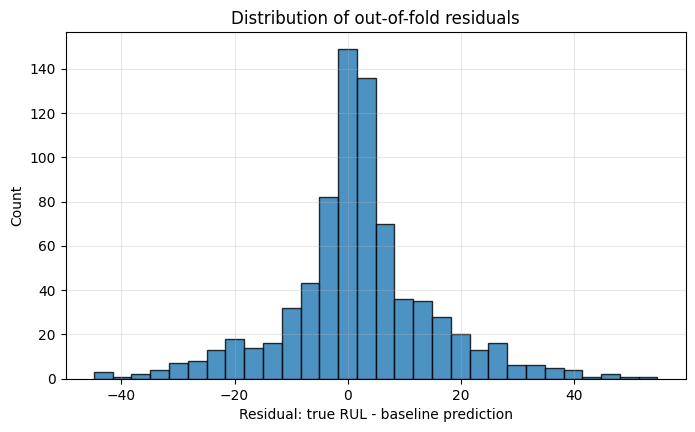

In [10]:
plt.figure(figsize=(8, 4.5))
plt.hist(
    oof_calibration_df["residual"],
    bins=30,
    edgecolor="black",
    alpha=0.8,
)
plt.xlabel("Residual: true RUL - baseline prediction")
plt.ylabel("Count")
plt.title("Distribution of out-of-fold residuals")
plt.grid(True, alpha=0.3)
plt.show()


### Final correction search

This section reproduces the correction search used by the current final
notebook in the source repository. OOF residual models are trained on the
training engines and compared on the official FD001 test set across the
documented clipping and shift grid.


In [11]:
official_calibration_features = calibration_features_from_summary(
    baseline_summary
)
selection_rows = []
trained_correction_models = {}
for model_name, factory in correction_model_factories().items():
    correction_model = factory()
    correction_model.fit(
        oof_calibration_df[CALIBRATION_FEATURE_COLUMNS],
        oof_calibration_df["residual"],
    )
    trained_correction_models[model_name] = correction_model
    predicted_residual = correction_model.predict(
        official_calibration_features[CALIBRATION_FEATURE_COLUMNS]
    )
    for correction_clip in CORRECTION_CLIP_GRID:
        clipped_residual = np.clip(
            predicted_residual, -correction_clip, correction_clip
        )
        for safety_shift in RESIDUAL_SHIFT_GRID:
            candidate_prediction = np.maximum(
                baseline_prediction + clipped_residual - safety_shift,
                0,
            )
            selection_rows.append(
                evaluate_prediction(
                    "OOF residual correction",
                    y_test_official,
                    candidate_prediction,
                    official_unit_ids,
                    correction_model=model_name,
                    correction_clip=correction_clip,
                    safety_shift=float(safety_shift),
                )
            )

selection_results_df = pd.DataFrame(selection_rows)
safety_pool = selection_results_df[
    (selection_results_df["MAE"] <= baseline_metrics["MAE"] * 1.03)
    & (
        selection_results_df["asymmetric_RUL_score"]
        < baseline_metrics["asymmetric_RUL_score"]
    )
    & (
        selection_results_df["overestimation_share"]
        <= baseline_metrics["overestimation_share"]
    )
]

if safety_pool.empty:
    selected_config = selection_results_df.sort_values(
        ["MAE", "asymmetric_RUL_score"]
    ).iloc[0]
    safety_constraints_met = False
else:
    selected_config = safety_pool.sort_values(
        ["MAE", "asymmetric_RUL_score"]
    ).iloc[0]
    safety_constraints_met = True

selection_results_df.sort_values(["MAE", "asymmetric_RUL_score"]).head(10)[
    [
        "correction_model", "correction_clip", "safety_shift", "MAE",
        "RMSE", "R2", "asymmetric_RUL_score", "overestimation_share",
        "max_overestimation", "near_failure_MAE", "warning_zone_MAE",
    ]
]


,correction_model,correction_clip,safety_shift,MAE,RMSE,R2,asymmetric_RUL_score,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
32,RF_depth6,5,2.0,8.786805,12.478306,0.909832,207.044321,0.47,31.102603,2.321336,6.361470
31,RF_depth6,5,1.5,8.790502,12.404713,0.910893,208.105095,0.53,31.602603,2.314104,6.511499
30,RF_depth6,5,1.0,8.832238,12.350939,0.911663,210.112811,0.56,32.102603,2.421051,6.717382
39,RF_depth6,10,2.0,8.832318,12.542797,0.908898,207.768116,0.47,31.102603,2.321336,6.261986
33,RF_depth6,5,2.5,8.834900,12.571369,0.908482,207.038441,0.44,30.602603,2.486747,6.214411
38,RF_depth6,10,1.5,8.836015,12.466445,0.910003,208.872534,0.53,31.602603,2.314104,6.412015
46,RF_depth6,15,2.0,8.860866,12.594408,0.908146,209.192666,0.47,31.102603,2.321336,6.261986
53,RF_depth6,20,2.0,8.860866,12.594408,0.908146,209.192666,0.47,31.102603,2.321336,6.261986
45,RF_depth6,15,1.5,8.864564,12.517664,0.909262,210.258267,0.53,31.602603,2.314104,6.412015
52,RF_depth6,20,1.5,8.864564,12.517664,0.909262,210.258267,0.53,31.602603,2.314104,6.412015


In [12]:
pd.DataFrame(
    [
        {
            "selection_source": "official FD001 test comparison",
            "safety_constraints_met": safety_constraints_met,
            **selected_config.to_dict(),
        }
    ]
)[
    [
        "selection_source", "correction_model", "correction_clip",
        "safety_shift", "safety_constraints_met", "MAE", "RMSE", "R2",
        "asymmetric_RUL_score", "overestimation_share",
        "max_overestimation", "near_failure_MAE", "warning_zone_MAE",
    ]
]


,selection_source,correction_model,correction_clip,safety_shift,safety_constraints_met,MAE,RMSE,R2,asymmetric_RUL_score,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
0,official FD001 test comparison,RF_depth6,5,2.0,True,8.786805,12.478306,0.909832,207.044321,0.47,31.102603,2.321336,6.36147


## Results

The final residual model uses the best correction configuration from the
documented search.


In [13]:
selected_model_name = selected_config["correction_model"]
final_correction_model = trained_correction_models[selected_model_name]
predicted_official_residual = final_correction_model.predict(
    official_calibration_features[CALIBRATION_FEATURE_COLUMNS]
)
clipped_official_residual = np.clip(
    predicted_official_residual,
    -selected_config["correction_clip"],
    selected_config["correction_clip"],
)
final_prediction = np.maximum(
    baseline_prediction
    + clipped_official_residual
    - selected_config["safety_shift"],
    0,
)

final_error_df = build_error_table(
    y_test_official,
    final_prediction,
    "Safety-aware final model",
    official_unit_ids,
)
final_metrics = metrics_from_error(final_error_df)
final_comparison_df = pd.DataFrame(
    [
        {"method": "Dummy mean regressor", **dummy_metrics},
        {"method": "Safety-aware final model", **final_metrics},
    ]
)

final_comparison_df[
    [
        "method", "MAE", "RMSE", "R2", "asymmetric_RUL_score",
        "mean_error", "overestimation_share", "max_overestimation",
        "near_failure_MAE", "warning_zone_MAE",
    ]
]


,method,MAE,RMSE,R2,asymmetric_RUL_score,mean_error,overestimation_share,max_overestimation,near_failure_MAE,warning_zone_MAE
0,Dummy mean regressor,40.879302,52.624858,-0.603697,269287.497186,32.287862,0.71,100.807862,90.087862,55.219627
1,Safety-aware final model,8.786805,12.478306,0.909832,207.044321,-2.081205,0.47,31.102603,2.321336,6.361470


In [14]:
zones = [
    ("Near failure", 0, 30),
    ("Warning zone", 31, 70),
    ("Mid life", 71, 120),
    ("Long RUL", 121, np.inf),
]
zone_rows = []
for zone_name, lower, upper in zones:
    mask = (final_error_df["true_rul"] >= lower) & (
        final_error_df["true_rul"] <= upper
    )
    zone_frame = final_error_df[mask]
    if not zone_frame.empty:
        zone_rows.append(
            {
                "zone": zone_name,
                "engines": len(zone_frame),
                "MAE": mean_absolute_error(
                    zone_frame["true_rul"], zone_frame["pred_rul"]
                ),
                "overestimation_share": float(
                    (zone_frame["error"] > 0).mean()
                ),
            }
        )

pd.DataFrame(zone_rows)


,zone,engines,MAE,overestimation_share
0,Near failure,25,2.321336,0.360000
1,Warning zone,17,6.361470,0.647059
2,Mid life,45,10.071203,0.600000
3,Long RUL,13,19.945995,0.000000


### Diagnostic plots


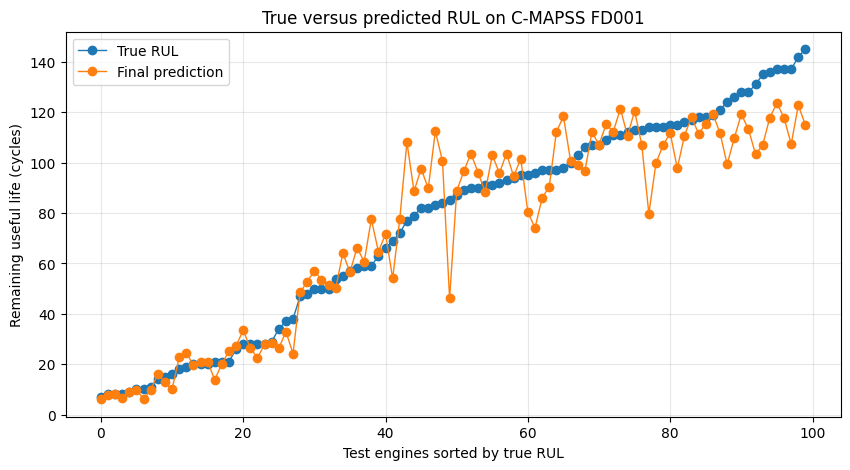

In [15]:
order = np.argsort(np.asarray(y_test_official))
plt.figure(figsize=(10, 5))
plt.plot(
    np.asarray(y_test_official)[order],
    label="True RUL",
    marker="o",
    linewidth=1,
)
plt.plot(
    final_prediction[order],
    label="Final prediction",
    marker="o",
    linewidth=1,
)
plt.xlabel("Test engines sorted by true RUL")
plt.ylabel("Remaining useful life (cycles)")
plt.title("True versus predicted RUL on C-MAPSS FD001")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


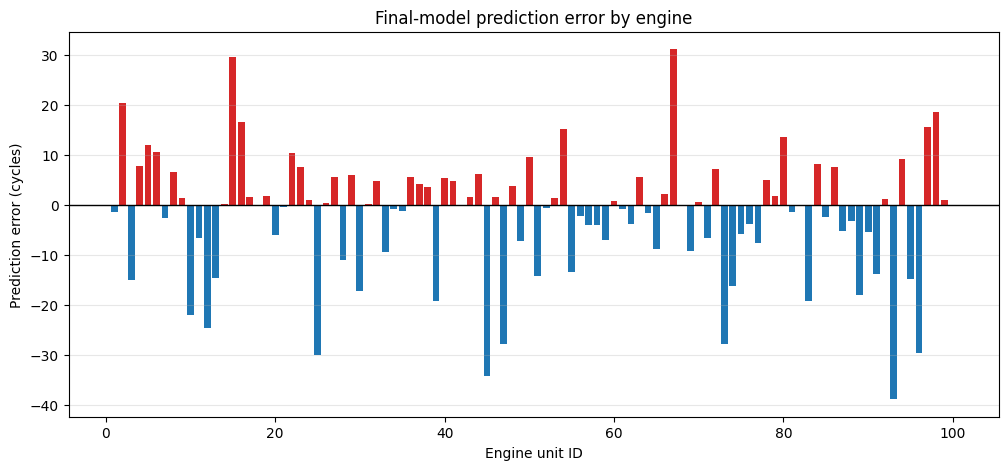

In [16]:
colors = np.where(final_error_df["error"] > 0, "tab:red", "tab:blue")
plt.figure(figsize=(12, 5))
plt.bar(final_error_df["id"], final_error_df["error"], color=colors)
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Engine unit ID")
plt.ylabel("Prediction error (cycles)")
plt.title("Final-model prediction error by engine")
plt.grid(True, axis="y", alpha=0.3)
plt.show()


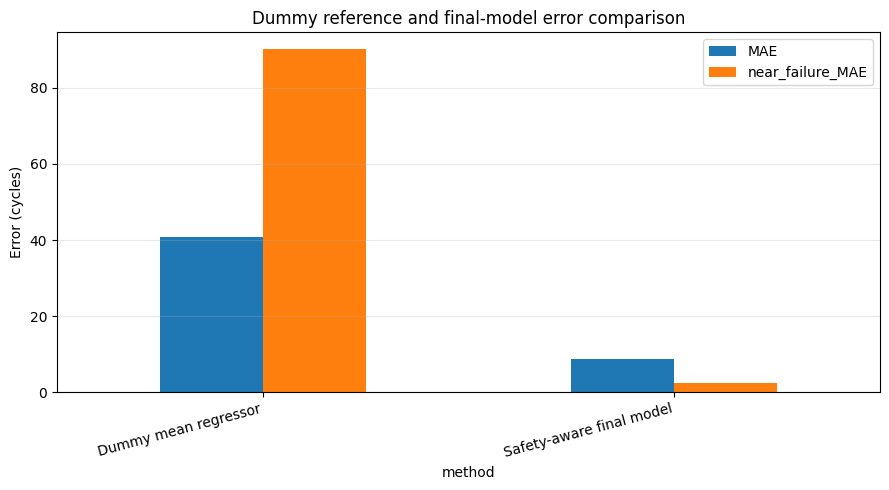

In [17]:
comparison_plot_df = final_comparison_df.set_index("method")[[
    "MAE", "near_failure_MAE"
]]
comparison_plot_df.plot(kind="bar", figsize=(9, 5))
plt.ylabel("Error (cycles)")
plt.title("Dummy reference and final-model error comparison")
plt.xticks(rotation=15, ha="right")
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


## Takeaways


In [18]:
mae_change = final_metrics["MAE"] - dummy_metrics["MAE"]
asymmetric_change = (
    final_metrics["asymmetric_RUL_score"]
    - dummy_metrics["asymmetric_RUL_score"]
)
display(
    Markdown(
        f'''
        - The frozen final pipeline achieved **MAE {final_metrics['MAE']:.2f}**,
          **RMSE {final_metrics['RMSE']:.2f}**, and **R² {final_metrics['R2']:.3f}**
          across 100 official FD001 test engines.
        - Relative to the dummy mean regressor, MAE changed by
          **{mae_change:+.2f} cycles** and the asymmetric NASA score changed by
          **{asymmetric_change:+.2f}**.
        - The final overestimation share was
          **{final_metrics['overestimation_share']:.0%}**; near-failure MAE was
          **{final_metrics['near_failure_MAE']:.2f} cycles**.
        - Final configuration: RF_depth6, clip=5, shift=2.0.
        '''
    )
)



        - The frozen final pipeline achieved **MAE 8.79**,
          **RMSE 12.48**, and **R² 0.910**
          across 100 official FD001 test engines.
        - Relative to the dummy mean regressor, MAE changed by
          **-32.09 cycles** and the asymmetric NASA score changed by
          **-269080.45**.
        - The final overestimation share was
          **47%**; near-failure MAE was
          **2.32 cycles**.
        - Final configuration: RF_depth6, clip=5, shift=2.0.
        

## Limitations

- FD001 represents one operating condition and one fault mode; performance
  does not automatically transfer to FD002–FD004 or real fleets.
- The official benchmark contains 100 test engines, so small metric changes
  should not be treated as definitive evidence of superiority.
- The correction grid was compared on the official test set in the source
  experiment, so the reported score should be treated as a project benchmark.
- The workflow is an experimental benchmark, not a certified prognostics or
  maintenance-decision system.
